# VIIRS Scene Preparation for Bayesian Chlorophyll-a Retrieval

## Overview

This notebook prepares VIIRS Level-2 ocean color data for application of Bayesian chlorophyll-a retrieval models. It handles data loading, quality control, spatial stitching, and storage in a standardized format for downstream analysis.

## Purpose

Satellite ocean color sensors like VIIRS acquire data in discrete swaths (granules) that must be combined to create continuous spatial coverage. This notebook:

1. **Loads multiple VIIRS L2 granules** from a target region
2. **Extracts relevant variables**: coordinates, remote sensing reflectance (Rrs), and NASA operational chlorophyll-a
3. **Applies quality filtering**: retains only pixels with valid, positive values across all required bands
4. **Stitches swaths** into a single spatially continuous dataset
5. **Saves to NetCDF** for efficient reuse in modeling workflows
6. **Generates verification plots** to ensure data integrity

## Study Region

**Target region**: Falkland Islands shelf and Southern Ocean  
**Scene date**: January 22, 2026  
**Swaths**: 4 sequential VIIRS granules  
**Coverage**: ~9.3 million valid pixels spanning 46° of longitude

This region was selected for its:
- Dynamic oceanographic conditions (shelf fronts, upwelling, Antarctic Circumpolar Current)
- Wide chlorophyll gradient (oligotrophic offshore to productive shelf waters)
- Optical complexity (multiple water types, seasonal sea ice influence)

## Data Source

**Sensor**: VIIRS (Visible Infrared Imaging Radiometer Suite) aboard Suomi-NPP  
**Product**: Level-2 Ocean Color (OC) Near Real-Time (NRT)  
**Variables extracted**:
- Navigation: latitude, longitude
- Geophysical: `chlor_a` (NASA OC3/OC6 algorithm)
- Remote sensing reflectance: `Rrs_410`, `Rrs_443`, `Rrs_486`, `Rrs_551`, `Rrs_671`

**Data access**: NASA Ocean Biology Distributed Active Archive Center (OB.DAAC)  
**Search tool**: `earthaccess` Python library

## Wavelength Considerations

VIIRS bands differ slightly from heritage sensors (SeaWiFS, MODIS):

| Feature | SeaWiFS/MODIS | VIIRS | Difference |
|---------|---------------|-------|------------|
| Blue 1 | 411 nm | 410 nm | -1 nm |
| Blue 2 | 443 nm | 443 nm | 0 nm |
| Blue 3 | 489 nm | 486 nm | -3 nm |
| Blue 4 | 510 nm | **N/A** | Missing |
| Green | 555 nm | 551 nm | -4 nm |
| Red | 670 nm | 671 nm | +1 nm |

**Implication**: Small wavelength shifts (1-4 nm) are acceptable and common in multi-sensor applications. The missing 510 nm band motivates a **3-group** Maximum Band Ratio (MBR) formulation rather than the traditional 4-group approach. This sensor-specific adaptation is handled in the modeling notebook.

## Quality Control

**Strict validity mask applied**:
- Coordinates must be finite (no NaN or Inf)
- NASA chlorophyll-a > 0 (excludes land, clouds, invalid retrievals)
- All 5 Rrs bands > 0 (required for MBR computation)

This conservative approach prioritizes data quality over coverage, ensuring all retained pixels can be used in Bayesian inference without additional filtering.

## Output

**File**: `viirs_falklands_stitched.nc`  
**Format**: NetCDF-4 with zlib compression  
**Size**: ~250 MB (9.3M pixels × 8 variables)  
**Variables**: longitude, latitude, chlor_a_nasa, Rrs_410, Rrs_443, Rrs_486, Rrs_551, Rrs_671  

**Metadata included**:
- Scene date and spatial extent
- Number of swaths and valid pixels
- Wavelength information
- Processing timestamp
- Usage notes for downstream analysis

## Usage

This notebook is **data preparation only**. The stitched NetCDF file is loaded in the modeling notebook (`03_modeling_workflow.ipynb`) for:
- Maximum Band Ratio (MBR) computation
- Bayesian hierarchical model application (Model 5-VIIRS)
- Uncertainty quantification via posterior predictive inference
- Comparison with NASA operational chlorophyll-a product

## Requirements
```python
# Core dependencies
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Optional: for NASA data access
import earthaccess
```

**Cartopy data**: First run may download Natural Earth shapefiles (~100 MB) for coastlines and land masks.

## Notes

- **Processing time**: ~2-5 minutes for 4 swaths depending on system
- **Memory usage**: ~2-3 GB peak (9.3M pixels in memory before saving)
- **Parallelization**: Not implemented; processing is I/O bound (reading L2 files)
- **Reproducibility**: Output NetCDF includes creation timestamp and provenance metadata

## Related Work

This data preparation workflow supports the analysis presented in:

> Karakӧylü, E.M. (2025). Uncertainty-aware chlorophyll-a retrieval from ocean color data using a Bayesian hierarchical framework. *Frontiers in Remote Sensing* (in preparation).

The full Bayesian modeling workflow, including model training, evaluation, and spatial application, is documented in the companion modeling notebook.

---

**Author**: Erdem M. Karakӧylü  
**Contact**: erdemk@protonmail.com  
**Repository**: https://github.com/erdemkarakoylu/bayesian_chl_pub  
**License**: MIT

In [ ]:
from pathlib import Path

import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as pp
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from helper_scripts import viirs_bayes_maps as vbm
# Project plotting standards
from helper_scripts.plot_style import set_plot_style, savefig
set_plot_style()

In [2]:
PROJ_PATH = Path(".").resolve()
DATA_PATH = PROJ_PATH / "data" 
L2_PATH = DATA_PATH / "L2_files"

In [31]:
auth = earthaccess.login()

In [ ]:
collections = earthaccess.search_datasets(
    keyword="Suomi-NPP VIIRS Level-2 Ocean Color",
)

print(f"Found {len(collections)} collections")
for c in collections[:15]:
    # these attributes exist on earthaccess DataCollection objects
    summ = c.summary()
    print(summ['short-name'], " | ", c.version(), " | ", c.provider())

In [26]:
bbox = (-40, -48, -20, -38)
date_range = ("2026-01-22", "2026-01-22")
short_name = "VIIRSN_L2_OC_NRT"

# Search for SNPP-VIIRS L2 granules
# Note: VNP09 (or similar) is the short_name for VIIRS L2 Ocean Color
results = earthaccess.search_data(
    short_name=short_name, 
    cloud_hosted=True,
    bounding_box=bbox, # (lower_left_lon, lat, upper_right_lon, lat)
    temporal=date_range,
    granule_name="SNPP_VIIRS*L2.OC*.nc"
)
results

[Collection: {'Version': '2022.0', 'ShortName': 'VIIRSN_L2_OC_NRT'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -38.28894, 'Longitude': -1.09353}, {'Latitude': -43.90075, 'Longitude': -37.94686}, {'Latitude': -64.54601, 'Longitude': -40.07588}, {'Latitude': -55.92623, 'Longitude': 16.80302}, {'Latitude': -38.28894, 'Longitude': -1.09353}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2026-01-22T15:12:00Z', 'EndingDateTime': '2026-01-22T15:17:59Z'}}
 Size(MB): 54.45765781402588
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/SNPP_VIIRS.20260122T151200.L2.OC.NRT.nc'],
 Collection: {'ShortName': 'VIIRSN_L2_OC_NRT', 'Version': '2022.0'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -18.79095, 'Longitude': -10.36986}, {'Latitude': -23.26653, 'Longitude': -39.75476}, {'Latitude': -44.02385, 'Longitude': -37.961

In [ ]:
# Download to a local folder
files = earthaccess.download(results, local_path=L2_PATH)

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
files = list(L2_PATH.glob("*NRT*"))
print(len(files))

4


In [15]:
# ============================================================================
# STITCH ALL DATA (Coordinates + NASA Chl + Rrs Bands)
# ============================================================================
# Uses strict validity mask: ALL data must be valid (finite, positive)
# This ensures lon/lat/chl/Rrs arrays are perfectly aligned
# ============================================================================

print("="*80)
print("STITCHING VIIRS SCENE: Coordinates + NASA Chl + Rrs Bands")
print("="*80)

# Initialize collectors
all_lons = []
all_lats = []
all_chls_nasa = []
rrs_collectors = {
    'Rrs_410': [],
    'Rrs_443': [],
    'Rrs_486': [],
    'Rrs_551': [],
    'Rrs_671': []
}

# Loop through L2 files
for l2_fp in files:
    try:
        with xr.open_dataset(l2_fp, group="geophysical_data") as geo, \
             xr.open_dataset(l2_fp, group="navigation_data") as nav:
            
            # Extract coordinates
            lat = nav["latitude"].values if "latitude" in nav else nav["lat"].values
            lon = nav["longitude"].values if "longitude" in nav else nav["lon"].values
            
            # Extract NASA chlor_a
            chl = geo["chlor_a"].values
            
            # Extract Rrs bands
            rrs_410 = geo["Rrs_410"].values
            rrs_443 = geo["Rrs_443"].values
            rrs_486 = geo["Rrs_486"].values
            rrs_551 = geo["Rrs_551"].values
            rrs_671 = geo["Rrs_671"].values
            
            # Strict validity mask: ALL data must be valid
            mask = (
                np.isfinite(lat) & 
                np.isfinite(lon) & 
                (chl > 0) &
                (rrs_410 > 0) &
                (rrs_443 > 0) &
                (rrs_486 > 0) &
                (rrs_551 > 0) &
                (rrs_671 > 0)
            )
            
            n_valid = mask.sum()
            if n_valid > 0:
                # Append coordinates and NASA chl
                all_lons.append(lon[mask])
                all_lats.append(lat[mask])
                all_chls_nasa.append(chl[mask])
                
                # Append Rrs bands
                rrs_collectors['Rrs_410'].append(rrs_410[mask])
                rrs_collectors['Rrs_443'].append(rrs_443[mask])
                rrs_collectors['Rrs_486'].append(rrs_486[mask])
                rrs_collectors['Rrs_551'].append(rrs_551[mask])
                rrs_collectors['Rrs_671'].append(rrs_671[mask])
                
                print(f"  ✓ {l2_fp.name}: {n_valid:,} valid pixels")
            else:
                print(f"  ⚠ {l2_fp.name}: 0 valid pixels (skipped)")
            
    except Exception as e:
        print(f"  ✗ {l2_fp.name}: ERROR - {e}")

print(f"\n{'='*80}")
print("CONCATENATING ARRAYS")
print("="*80)

# Concatenate all swaths
stitched_lon = np.concatenate(all_lons)
stitched_lat = np.concatenate(all_lats)
stitched_chl = np.concatenate(all_chls_nasa)

stitched_rrs = {}
for band in rrs_collectors.keys():
    stitched_rrs[band] = np.concatenate(rrs_collectors[band])

n_pixels = len(stitched_lon)

print(f"\n✓ STITCHING COMPLETE: {n_pixels:,} valid pixels from {len(files)} swaths")

# Verify all arrays have same length
print(f"\n{'='*80}")
print("VERIFICATION")
print("="*80)

assert len(stitched_lat) == n_pixels, "Latitude length mismatch!"
assert len(stitched_chl) == n_pixels, "Chlorophyll length mismatch!"

for band in stitched_rrs.keys():
    assert len(stitched_rrs[band]) == n_pixels, f"{band} length mismatch!"
    
print(f"✓ All arrays have consistent length: {n_pixels:,} pixels")

# Summary statistics
print(f"\n{'='*80}")
print("DATA SUMMARY")
print("="*80)

print(f"\nCoordinates:")
print(f"  Longitude: [{stitched_lon.min():.2f}, {stitched_lon.max():.2f}]°E")
print(f"  Latitude:  [{stitched_lat.min():.2f}, {stitched_lat.max():.2f}]°N")

print(f"\nNASA Chlorophyll-a:")
print(f"  Range: [{stitched_chl.min():.4f}, {stitched_chl.max():.4f}] mg m⁻³")
print(f"  Median: {np.median(stitched_chl):.4f} mg m⁻³")

print(f"\nRrs Ranges (sr⁻¹):")
for band in ['Rrs_410', 'Rrs_443', 'Rrs_486', 'Rrs_551', 'Rrs_671']:
    rrs_data = stitched_rrs[band]
    print(f"  {band}: [{rrs_data.min():.6f}, {rrs_data.max():.6f}]")

print(f"\n{'='*80}")
print("✓ STEP 1 COMPLETE: All data stitched and verified")
print("="*80)

STITCHING VIIRS SCENE: Coordinates + NASA Chl + Rrs Bands
  ✓ SNPP_VIIRS.20260122T151200.L2.OC.NRT.nc: 419,333 valid pixels
  ✓ SNPP_VIIRS.20260122T165400.L2.OC.NRT.nc: 2,675,477 valid pixels
  ✓ SNPP_VIIRS.20260122T151801.L2.OC.NRT.nc: 4,201,303 valid pixels
  ✓ SNPP_VIIRS.20260122T170000.L2.OC.NRT.nc: 2,036,164 valid pixels

CONCATENATING ARRAYS

✓ STITCHING COMPLETE: 9,332,277 valid pixels from 4 swaths

VERIFICATION
✓ All arrays have consistent length: 9,332,277 pixels

DATA SUMMARY

Coordinates:
  Longitude: [-63.49, 10.73]°E
  Latitude:  [-63.09, -17.22]°N

NASA Chlorophyll-a:
  Range: [0.0010, 245.4003] mg m⁻³
  Median: 0.1510 mg m⁻³

Rrs Ranges (sr⁻¹):
  Rrs_410: [0.000002, 0.115534]
  Rrs_443: [0.000006, 0.115534]
  Rrs_486: [0.000020, 0.115534]
  Rrs_551: [0.000004, 0.115534]
  Rrs_671: [0.000002, 0.043592]

✓ STEP 1 COMPLETE: All data stitched and verified


In [16]:
# ============================================================================
# SAVE STITCHED DATA TO NETCDF
# ============================================================================

import xarray as xr
from datetime import datetime

print("="*80)
print("SAVING STITCHED DATA TO NETCDF")
print("="*80)

# Create xarray Dataset
ds_stitched = xr.Dataset(
    {
        # Coordinates
        "longitude": (["pixel"], stitched_lon),
        "latitude": (["pixel"], stitched_lat),
        
        # NASA chlorophyll-a product (for comparison)
        "chlor_a_nasa": (["pixel"], stitched_chl),
        
        # Rrs bands (VIIRS wavelengths)
        "Rrs_410": (["pixel"], stitched_rrs['Rrs_410']),
        "Rrs_443": (["pixel"], stitched_rrs['Rrs_443']),
        "Rrs_486": (["pixel"], stitched_rrs['Rrs_486']),
        "Rrs_551": (["pixel"], stitched_rrs['Rrs_551']),
        "Rrs_671": (["pixel"], stitched_rrs['Rrs_671']),
    },
    coords={
        "pixel": np.arange(len(stitched_lon))
    },
    attrs={
        "title": "Stitched VIIRS L2 Scene - Falklands/Southern Ocean Region",
        "description": "4 swaths merged, valid pixels only (all Rrs > 0, Chl > 0)",
        "scene_date": "2026-01-22",
        "n_swaths": len(files),
        "n_pixels": len(stitched_lon),
        "date_created": str(datetime.now()),
        "wavelengths_nm": "410, 443, 486, 551, 671 (VIIRS native)",
        "note": "Use Rrs_410→411, Rrs_486→489, Rrs_551→555 in MBR calculation"
    }
)

# Add variable metadata
ds_stitched["longitude"].attrs = {
    "units": "degrees_east", 
    "long_name": "Longitude",
    "valid_range": [-180, 180]
}

ds_stitched["latitude"].attrs = {
    "units": "degrees_north", 
    "long_name": "Latitude",
    "valid_range": [-90, 90]
}

ds_stitched["chlor_a_nasa"].attrs = {
    "units": "mg m-3", 
    "long_name": "NASA Chlorophyll-a Concentration (OC3/OC6 algorithm)",
    "algorithm": "OC3 or OC6 (sensor-dependent)",
    "source": "VIIRS Level-2 geophysical_data/chlor_a"
}

for band_nm in [410, 443, 486, 551, 671]:
    band_name = f"Rrs_{band_nm}"
    ds_stitched[band_name].attrs = {
        "units": "sr-1",
        "long_name": f"Remote Sensing Reflectance at {band_nm} nm",
        "wavelength_nm": band_nm
    }

# Save to NetCDF
output_file = L2_PATH / "viirs_falklands_stitched.nc"
print(f"\nSaving to: {output_file}")

# Use compression to reduce file size (9.3M pixels is large!)
encoding = {var: {"zlib": True, "complevel": 4} for var in ds_stitched.data_vars}

ds_stitched.to_netcdf(output_file, encoding=encoding)

file_size_mb = output_file.stat().st_size / 1e6

print(f"✓ File saved successfully")
print(f"  Size: {file_size_mb:.1f} MB")
print(f"  Location: {output_file}")

# Verification: reload and check
print(f"\n{'='*80}")
print("VERIFICATION: Reloading file")
print("="*80)

ds_test = xr.open_dataset(output_file)
print(f"\nDataset contents:")
print(ds_test)

print(f"\n✓ File loads successfully")
print(f"  Variables: {list(ds_test.data_vars)}")
print(f"  Dimensions: {dict(ds_test.dims)}")

ds_test.close()

print(f"\n{'='*80}")
print("✓ STEP 2 COMPLETE: Stitched data saved to NetCDF")
print("="*80)

SAVING STITCHED DATA TO NETCDF

Saving to: /Users/erdemkarakoylu/projex/bayesian_chl/data/L2_files/viirs_falklands_stitched.nc
✓ File saved successfully
  Size: 249.2 MB
  Location: /Users/erdemkarakoylu/projex/bayesian_chl/data/L2_files/viirs_falklands_stitched.nc

VERIFICATION: Reloading file

Dataset contents:
<xarray.Dataset> Size: 373MB
Dimensions:       (pixel: 9332277)
Coordinates:
  * pixel         (pixel) int64 75MB 0 1 2 3 ... 9332273 9332274 9332275 9332276
Data variables:
    longitude     (pixel) float32 37MB ...
    latitude      (pixel) float32 37MB ...
    chlor_a_nasa  (pixel) float32 37MB ...
    Rrs_410       (pixel) float32 37MB ...
    Rrs_443       (pixel) float32 37MB ...
    Rrs_486       (pixel) float32 37MB ...
    Rrs_551       (pixel) float32 37MB ...
    Rrs_671       (pixel) float32 37MB ...
Attributes:
    title:           Stitched VIIRS L2 Scene - Falklands/Southern Ocean Region
    description:     4 swaths merged, valid pixels only (all Rrs > 0, Chl > 

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_25753/1060309281.py:98: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensions: {dict(ds_test.dims)}")


In [11]:
stitched_log_chl = np.log10(stitched_chl)

Text(0.5, 1.0, 'Stitched VIIRS L2 Scene with Cartopy Land Mask')

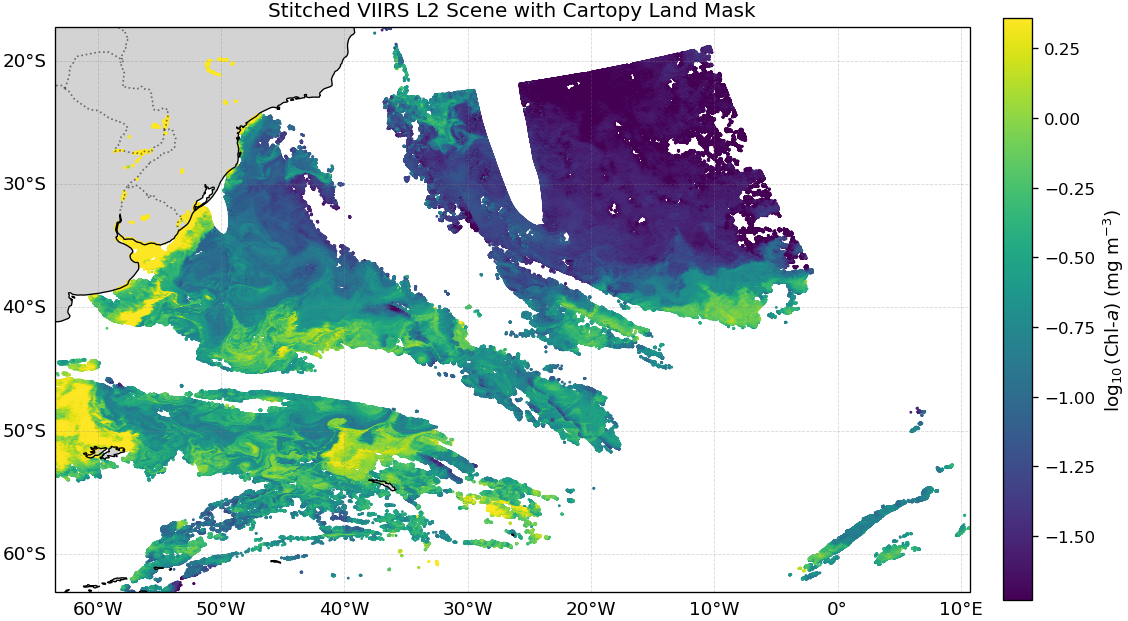

In [12]:
# 1. Reuse the stitched data we created earlier
# (Assuming stitched_lon, stitched_lat, stitched_log_chl are already defined)

# 2. Setup Figure and Cartopy Axis
proj = ccrs.PlateCarree()
fig = pp.figure(figsize=(12, 9))
ax = pp.axes(projection=proj)

# 3. Add Land and Geography
# We use '50m' resolution; you can use '10m' if your ROI is very small.
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, zorder=2)

# 4. Set the ROI Extent 
# This prevents the "whole world" view and matches your 4-panel limits
extent = [stitched_lon.min(), stitched_lon.max(), stitched_lat.min(), stitched_lat.max()]
ax.set_extent(extent, crs=proj)

# 5. Plot the Stitched Data
# Crucial: transform=proj tells Cartopy the data is in lon/lat degrees
sc = ax.scatter(
    stitched_lon, 
    stitched_lat, 
    c=stitched_log_chl, 
    s=0.5, 
    norm=shared_norm, # Use the same norm from the 4-panel figure for consistency
    cmap='viridis',
    transform=proj,
    rasterized=True   # Vital for stitched scenes to keep file sizes manageable
)

# 6. Add Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# 7. Add Colorbar
cbar = pp.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label(r"$\log_{10}(\text{Chl-}a)$ (mg m$^{-3}$)")

ax.set_title("Stitched VIIRS L2 Scene with Cartopy Land Mask")


GENERATING VERIFICATION PLOT
NASA Chl color scale: [-1.73, 0.33] log10(mg m⁻³)


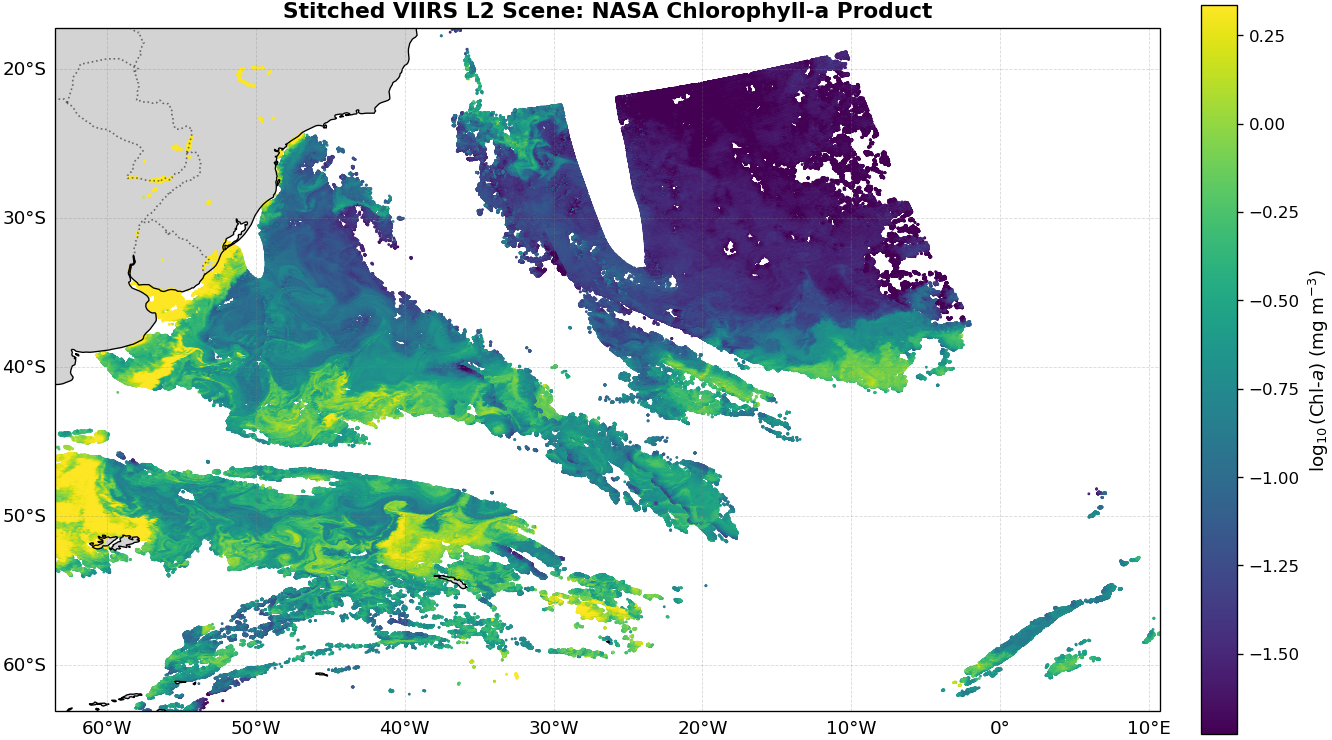


✓ Verification plot complete


In [17]:
# ============================================================================
# BASIC VISUALIZATION: Verify Stitched Data
# ============================================================================

print("="*80)
print("GENERATING VERIFICATION PLOT")
print("="*80)

# Compute log(Chl) for NASA product
stitched_log_chl = np.log10(stitched_chl)

# Calculate color scale (clip extreme outliers)
vmin = np.nanpercentile(stitched_log_chl, 2)
vmax = np.nanpercentile(stitched_log_chl, 98)
shared_norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

print(f"NASA Chl color scale: [{vmin:.2f}, {vmax:.2f}] log10(mg m⁻³)")

# Setup Figure and Cartopy Axis
proj = ccrs.PlateCarree()
fig = pp.figure(figsize=(12, 9))
ax = pp.axes(projection=proj)

# Add Land and Geography
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, zorder=2)

# Set the ROI Extent
extent = [stitched_lon.min(), stitched_lon.max(), 
          stitched_lat.min(), stitched_lat.max()]
ax.set_extent(extent, crs=proj)

# Plot the Stitched Data
sc = ax.scatter(
    stitched_lon, 
    stitched_lat, 
    c=stitched_log_chl, 
    s=0.5, 
    norm=shared_norm,
    cmap='viridis',
    transform=proj,
    rasterized=True  # Vital for large scenes to keep file sizes manageable
)

# Add Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Add Colorbar
cbar = pp.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, pad=0.03)
cbar.set_label(r"$\log_{10}(\mathrm{Chl}\text{-}a)$ (mg m$^{-3}$)", fontsize=11)

ax.set_title("Stitched VIIRS L2 Scene: NASA Chlorophyll-a Product", fontsize=13, weight='bold')

pp.tight_layout()
pp.show()

print("\n✓ Verification plot complete")
print("="*80)